# EDA: biological signal

is there signal worth modeling? reproduce key paper findings to validate data integrity.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import warnings
warnings.filterwarnings('ignore', message='.*coroutine.*was never awaited.*')
warnings.filterwarnings('ignore', message='.*Task was destroyed.*')
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import pyreadr
import subprocess, io

Image.MAX_IMAGE_PIXELS = None

ROOT = Path().resolve().parents[1]
DATA = ROOT / 'data' / 'inputs'

sns.set_theme(style='ticks', palette='Dark2', context='notebook')

# gene ID mapping: ensembl -> symbol
# paper quantified with Salmon 0.38 against GRCh38/hg38 (GENCODE v38).
# mapping from Ensembl biomart (GRCh38). coverage: ~81% of 30270 genes mapped.
gene_map = pd.read_csv(DATA / 'ensembl_to_symbol.tsv', sep='\t')
ens2sym = dict(zip(gene_map['ensembl_id'], gene_map['gene_symbol']))

def load_counts_with_symbols(path):
    """load a count matrix and map ensembl IDs to gene symbols for display only"""
    df = pd.read_csv(path, sep='\t', compression='bz2', index_col=0)
    new_cols = {c: ens2sym.get(c.split('.')[0], c) for c in df.columns}
    return df.rename(columns=new_cols)

def read_rds_matrix(path):
    """read an RDS file containing an R matrix via Rscript, return as pandas DataFrame.
    pyreadr can't handle matrix objects; rpy2 requires matching R version (have 4.4, rpy2 wants 4.5).
    subprocess is the reliable fallback."""
    r = subprocess.run(
        ['Rscript', '-e', f'x <- readRDS("{path}"); write.csv(x, stdout())'],
        capture_output=True, text=True
    )
    if r.returncode != 0:
        raise RuntimeError(f'Rscript failed on {path}: {r.stderr}')
    return pd.read_csv(io.StringIO(r.stdout), index_col=0)

## 1. patient-array pairing (ids.RDS)
verify the mapping between patients, slides, and subarrays matches the published cohort structure.

In [2]:
# ids.RDS maps subarrays -> patients
ids = pyreadr.read_r(DATA / 'Clinical' / 'ids.RDS')[None]
clinical = pd.read_excel(DATA / 'Clinical' / 'Clinical.xlsx')

print(f'subarrays in ids.RDS: {len(ids)}')
print(f'unique patients (id col): {ids["id"].nunique()}')
print(f'patients in clinical: {len(clinical)}')
print(f'subarrays with morphological annotations: {ids["hasAnnot"].sum()}')

# subarrays per patient
subs_per_patient = ids.groupby('id').size()
print(f'\nsubarrays per patient: min={subs_per_patient.min()}, max={subs_per_patient.max()}, median={subs_per_patient.median():.0f}')

# paper (p3): "94 early-stage TNBC patients", "281 out of the 288 subarrays",
# "corresponding to 92 out of 94 patients" (TNBC 17 and 18 failed QC)
# however: IDs 17 and 18 are absent from both clinical.xlsx and ids.RDS.
# the Zenodo release contains 94 patients (IDs 1-96, skipping 17/18) with 281 subarrays.
# all 94 have complete annotations. all 94 are TNBC (ER=0 for all; 2 patients have
# low PR IHC scores of 2-3 but below clinical TNBC threshold; 6 patients have HER2 1+
# which is clinically HER2-negative). no normal tissue or non-TNBC controls are present.

# available classification annotations:
annot_cols = {
    'Bareche_molecular_subtype_defined_on_global_pseudobulk': 'subtype (global)',
    'Bareche_molecular_subtype_defined_on_tumor_pseudobulk': 'subtype (tumor compartment)',
    'Bareche_molecular_subtype_defined_on_stroma_pseudobulk': 'subtype (stroma compartment)',
    'TIME_classes.by.pathologist': 'TIME (pathologist)',
    'TIME_classes_expression_bulk': 'TIME (bulk expression)',
    'TIME_classes_expression_global_pseudobulk': 'TIME (ST expression)',
    'Spatial archetypes_defined_on_ST_global_pseudobulk': 'spatial archetype',
}
print('\navailable annotations:')
for col, label in annot_cols.items():
    n = clinical[col].notna().sum()
    vals = clinical[col].value_counts().to_dict()
    print(f'  {label}: {n}/94 - {vals}')

ids.head(10)

subarrays in ids.RDS: 281
unique patients (id col): 94
patients in clinical: 94
subarrays with morphological annotations: 94

subarrays per patient: min=2, max=3, median=3

available annotations:
  subtype (global): 94/94 - {'M': 28, 'IM': 25, 'BL': 18, 'MSL': 12, 'LAR': 11}
  subtype (tumor compartment): 94/94 - {'BL': 41, 'M': 33, 'LAR': 14, 'IM': 6}
  subtype (stroma compartment): 94/94 - {'MSL': 36, 'IM': 32, 'M': 14, 'LAR': 7, 'BL': 5}
  TIME (pathologist): 94/94 - {'SR': 34, 'ID': 23, 'MR': 19, 'FI': 17, 'nd': 1}
  TIME (bulk expression): 85/94 - {'Margin restricted': 38, 'Stroma Restricted': 27, 'Fully Inflamed': 20}
  TIME (ST expression): 85/94 - {'Margin restricted': 38, 'Stroma Restricted': 25, 'Fully Inflamed': 22}
  spatial archetype: 94/94 - {4: 16, 7: 15, 2: 14, 5: 13, 6: 8, 9: 8, 3: 8, 8: 6, 1: 6}


,NGI.Sample.ID,Your.sample.name,Custom.index,plate,slide,ID,subslide,idx2,count,id,hasAnnot
rownames,,,,,,,,,,,
CN1_C1,P13202_1001,CN 1:Sample 1:C1,ATATGCGC-CTGATCGT,Plate 1.xlsx,CN1,Sample 1,C1,CTGATCGT-ATATGCGC,P13202_1001_S1_L001_stdata.tsv.bz2,1,True
CN1_C2,P13202_1002,CN 1:Sample 1:C2,TGGTACAG-ACTCTCGA,Plate 1.xlsx,CN1,Sample 1,C2,ACTCTCGA-TGGTACAG,P13202_1002_S2_L001_stdata.tsv.bz2,1,False
CN1_D1,P13202_1003,CN 1:Sample 1:D1,AACCGTTC-TGAGCTAG,Plate 1.xlsx,CN1,Sample 1,D1,TGAGCTAG-AACCGTTC,P13202_1003_S3_L001_stdata.tsv.bz2,1,False
CN1_D2,P13202_1004,CN 1:Sample 2:D2,TAACCGGT-GAGACGAT,Plate 1.xlsx,CN1,Sample 2,D2,GAGACGAT-TAACCGGT,P13202_1004_S4_L001_stdata.tsv.bz2,2,False
CN1_E1,P13202_1005,CN 1:Sample 2:E1,GAACATCG-CTTGTCGA,Plate 1.xlsx,CN1,Sample 2,E1,CTTGTCGA-GAACATCG,P13202_1005_S5_L001_stdata.tsv.bz2,2,True
CN1_E2,P13202_1006,CN 1:Sample 2:E2,CCTTGTAG-TTCCAAGG,Plate 1.xlsx,CN1,Sample 2,E2,TTCCAAGG-CCTTGTAG,P13202_1006_S6_L001_stdata.tsv.bz2,2,False
CN2_C1,P13202_1007,CN 2:Sample 3:C1,TCAGGCTT-CGCATGAT,Plate 1.xlsx,CN2,Sample 3,C1,CGCATGAT-TCAGGCTT,P13202_1007_S7_L001_stdata.tsv.bz2,3,True
CN2_E2,P13202_1012,CN 2:Sample 3:E2,CACCTGTT-GCTATCCT,Plate 1.xlsx,CN2,Sample 3,E2,GCTATCCT-CACCTGTT,P13202_1012_S12_L001_stdata.tsv.bz2,4,False
CN2_D1,P13202_1009,CN 2:Sample 3:D1,AGAACGAG-CGGCTAAT,Plate 1.xlsx,CN2,Sample 3,D1,CGGCTAAT-AGAACGAG,P13202_1009_S9_L001_stdata.tsv.bz2,3,False


## 2. molecular subtypes + TIME + spatial archetypes
check that the known biological classifications from the paper are present and distributed as expected across patients.

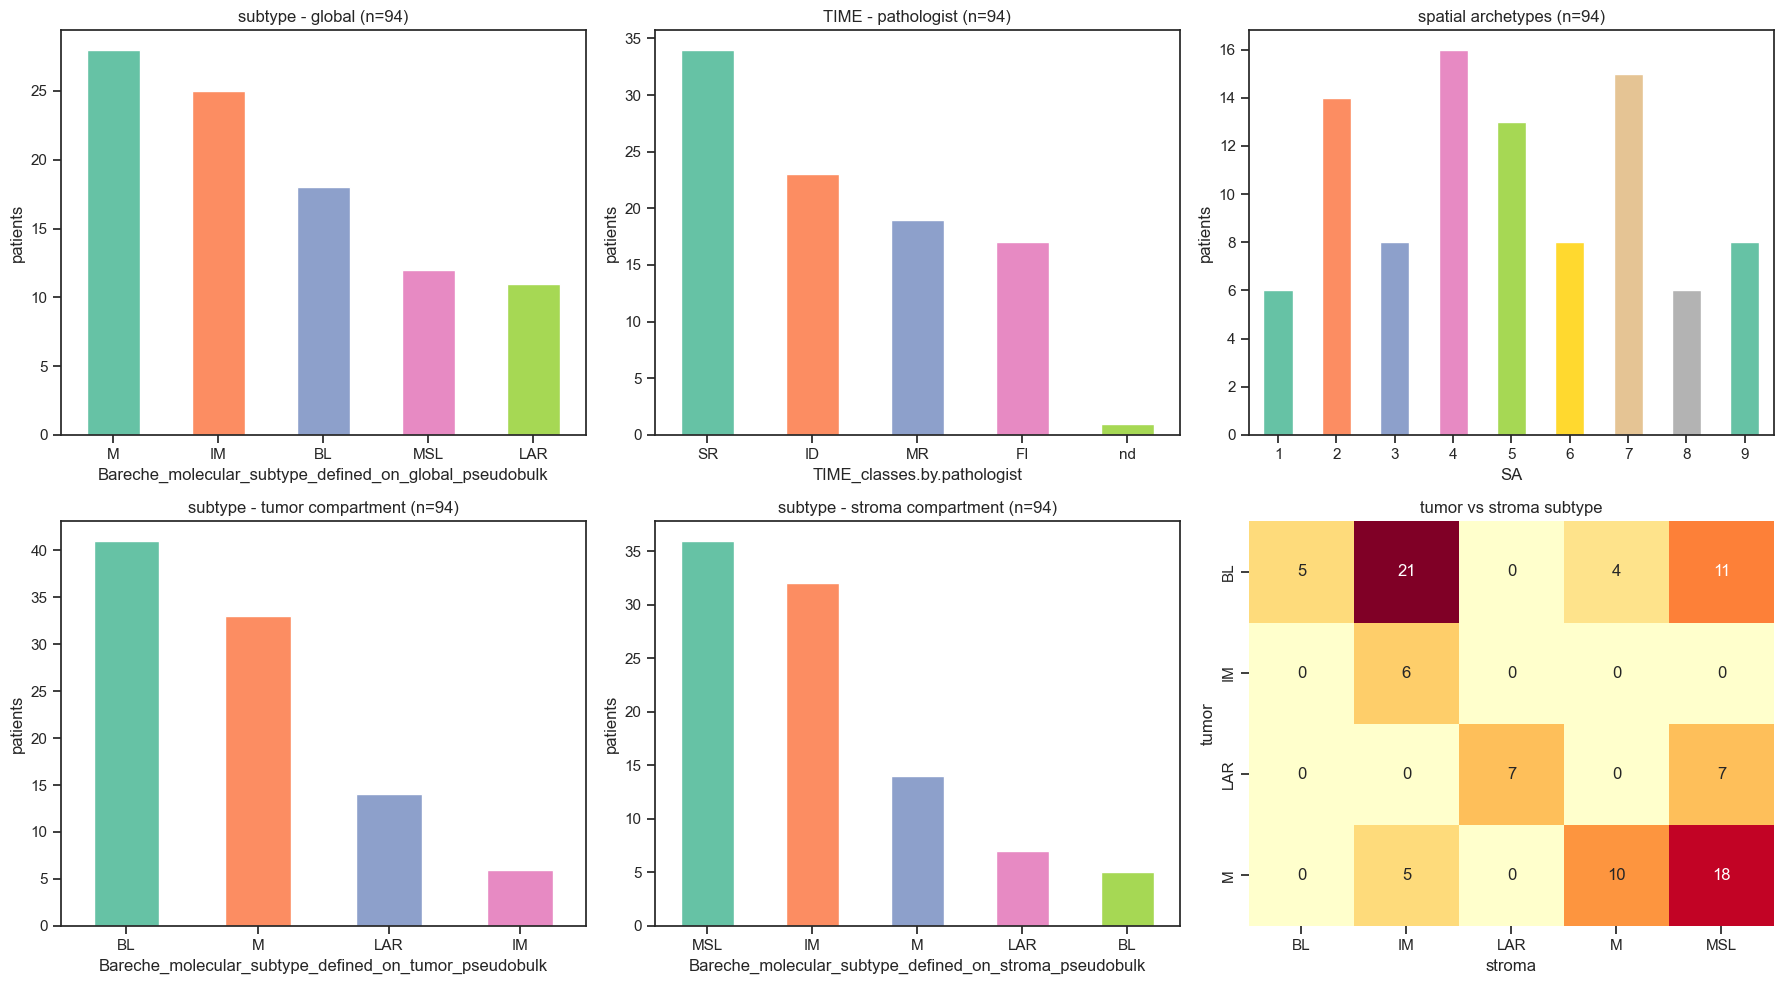

subtype x TIME:
TIME_classes.by.pathologist                         FI  ID  MR  SR  nd
Bareche_molecular_subtype_defined_on_global_pse...                    
BL                                                   2   0   5  11   0
IM                                                  12   1   3   9   0
LAR                                                  0   5   2   4   0
M                                                    2  12   8   6   0
MSL                                                  1   5   1   4   1

tumor compartment subtypes: ['LAR', 'M', 'BL', 'IM']
stroma compartment subtypes: ['LAR', 'MSL', 'IM', 'M', 'BL']
global == tumor subtype: 53/94 (56%)


In [3]:
# paper (p3): 5 TNBC molecular subtypes (Bareche classification on global pseudobulk)
# paper (p3): TIME classification by pathologist (FI, SR, MR, ID)
# paper (p9): 9 spatial archetypes from hierarchical clustering of 14 megaclusters
# paper (p4-5): tumor and stroma compartments classify differently - key spatial heterogeneity

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# row 1: global subtype, TIME, spatial archetypes
sub_col = 'Bareche_molecular_subtype_defined_on_global_pseudobulk'
clinical[sub_col].value_counts().plot(kind='bar', ax=axes[0, 0], color=sns.color_palette('Set2'))
axes[0, 0].set_title(f'subtype - global (n={clinical[sub_col].notna().sum()})')
axes[0, 0].set_ylabel('patients')
axes[0, 0].tick_params(axis='x', rotation=0)

time_col = 'TIME_classes.by.pathologist'
clinical[time_col].value_counts().plot(kind='bar', ax=axes[0, 1], color=sns.color_palette('Set2'))
axes[0, 1].set_title(f'TIME - pathologist (n={clinical[time_col].notna().sum()})')
axes[0, 1].set_ylabel('patients')
axes[0, 1].tick_params(axis='x', rotation=0)

sa_col = 'Spatial archetypes_defined_on_ST_global_pseudobulk'
clinical[sa_col].value_counts().sort_index().plot(kind='bar', ax=axes[0, 2], color=sns.color_palette('Set2'))
axes[0, 2].set_title(f'spatial archetypes (n={clinical[sa_col].notna().sum()})')
axes[0, 2].set_ylabel('patients')
axes[0, 2].set_xlabel('SA')
axes[0, 2].tick_params(axis='x', rotation=0)

# row 2: tumor vs stroma compartment subtypes + cross-tab
tumor_col = 'Bareche_molecular_subtype_defined_on_tumor_pseudobulk'
stroma_col = 'Bareche_molecular_subtype_defined_on_stroma_pseudobulk'

clinical[tumor_col].value_counts().plot(kind='bar', ax=axes[1, 0], color=sns.color_palette('Set2'))
axes[1, 0].set_title(f'subtype - tumor compartment (n={clinical[tumor_col].notna().sum()})')
axes[1, 0].set_ylabel('patients')
axes[1, 0].tick_params(axis='x', rotation=0)

clinical[stroma_col].value_counts().plot(kind='bar', ax=axes[1, 1], color=sns.color_palette('Set2'))
axes[1, 1].set_title(f'subtype - stroma compartment (n={clinical[stroma_col].notna().sum()})')
axes[1, 1].set_ylabel('patients')
axes[1, 1].tick_params(axis='x', rotation=0)

# cross-tab: do tumor and stroma agree?
ct = pd.crosstab(clinical[tumor_col], clinical[stroma_col])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 2], cbar=False)
axes[1, 2].set_title('tumor vs stroma subtype')
axes[1, 2].set_xlabel('stroma')
axes[1, 2].set_ylabel('tumor')

plt.tight_layout()
plt.show()

# paper (p4): tumor compartment only has 3 subtypes (LAR, M, BL) while stroma has all 5
# this means IM and MSL subtypes are driven by stroma, not tumor cells
print('subtype x TIME:')
print(pd.crosstab(clinical[sub_col], clinical[time_col]))
print()
print('tumor compartment subtypes:', clinical[tumor_col].unique().tolist())
print('stroma compartment subtypes:', clinical[stroma_col].unique().tolist())
agree = (clinical[sub_col] == clinical[tumor_col]).sum()
print(f'global == tumor subtype: {agree}/94 ({agree/94*100:.0f}%)')

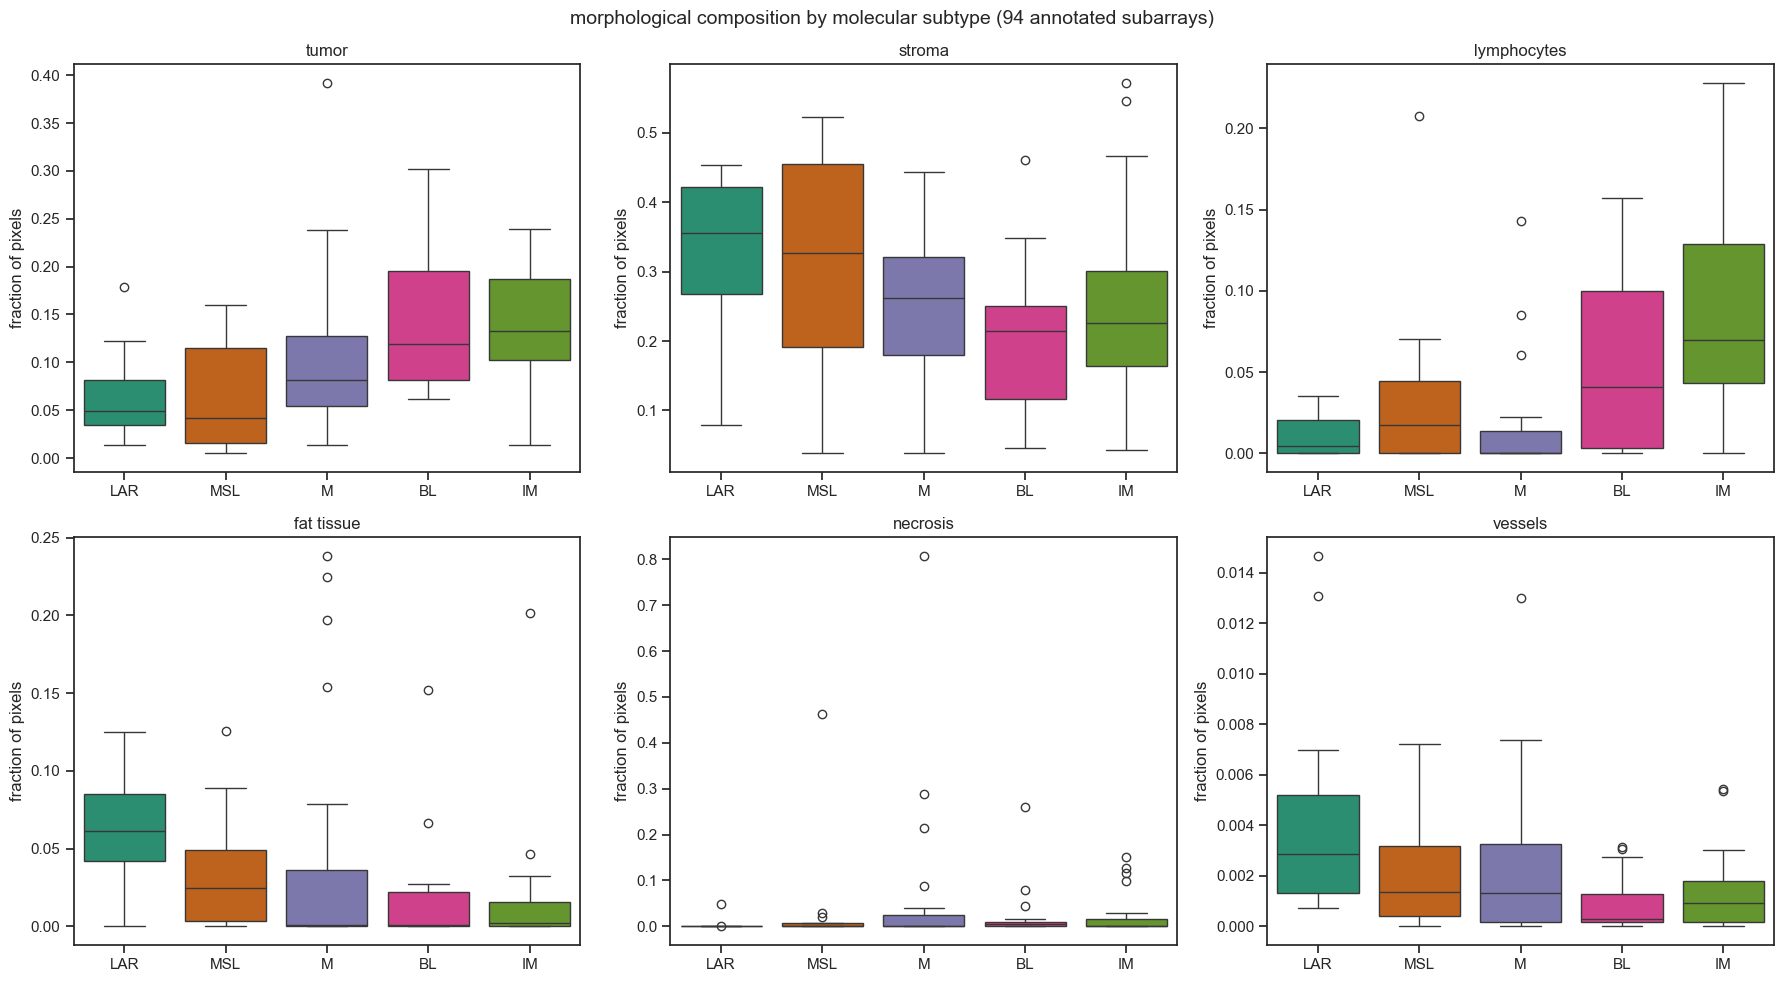

mean tumor fraction by subtype:
subtype
BL     0.143
IM     0.130
M      0.103
LAR    0.065
MSL    0.065

mean stroma fraction by subtype:
subtype
LAR    0.327
MSL    0.309
M      0.255
IM     0.255
BL     0.208


In [4]:
# morphological composition by subtype (parallels paper figure 3c)
# loaded from annotBySpot.RDS via Rscript - pixel fractions per morphological category per spot,
# averaged per subarray, then grouped by molecular subtype

morph_df = pd.read_csv(DATA / 'morphological_fractions.tsv', sep='\t')

# paper merges 18 categories to 9: Tumor (Tumor + Tumor region + in situ),
# Stroma (Stroma cell + Low TIL stroma + High TIL stroma + Acellular stroma),
# Lymphocytes, Fat tissue, Vessels, Necrosis, Lactiferous duct, TLS (Lymphoid nodule), Nerve
morph_df['Tumor_merged'] = morph_df[['Tumor', 'Tumor region', 'in situ']].sum(axis=1)
morph_df['Stroma_merged'] = morph_df[['Stroma cell', 'Low TIL stroma', 'High TIL stroma', 'Acellular stroma']].sum(axis=1)

plot_cats = ['Tumor_merged', 'Stroma_merged', 'Lymphocyte', 'Fat tissue', 'Necrosis', 'Vessels']
cat_labels = ['tumor', 'stroma', 'lymphocytes', 'fat tissue', 'necrosis', 'vessels']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

order = ['LAR', 'MSL', 'M', 'BL', 'IM']
for ax, cat, label in zip(axes, plot_cats, cat_labels):
    sns.boxplot(data=morph_df, x='subtype', y=cat, order=order, ax=ax, palette='Dark2')
    ax.set_title(label)
    ax.set_ylabel('fraction of pixels')
    ax.set_xlabel('')

plt.suptitle('morphological composition by molecular subtype (94 annotated subarrays)', fontsize=14)
plt.tight_layout()
plt.show()

# paper (p3-4): IM, BL, M enriched in tumor; LAR, MSL enriched in stroma
# check if we see the same pattern
print('mean tumor fraction by subtype:')
print(morph_df.groupby('subtype')['Tumor_merged'].mean().sort_values(ascending=False).round(3).to_string())
print()
print('mean stroma fraction by subtype:')
print(morph_df.groupby('subtype')['Stroma_merged'].mean().sort_values(ascending=False).round(3).to_string())

## 3. spot filtering - reproduce paper QC
determine which spots are on-tissue vs off-tissue by comparing allSpots (full grid) to selectionSpots (tissue-filtered) across all subarrays, and validate totals against the paper.

In [5]:
# paper (p15): "537,069 spots" pre-filter, "270,310 spots" after all QC
# paper (p15): filtered spots outside tissue, >1% artifact pixels, <500 UMI
# paper (p3): "a median of 960 spots per subarray and a median of 2554 genes"
# paper (p15): normalization: Log(1 + 10000x/Σx), batch corrected per gene

count_files = sorted([f for f in (DATA / 'rawCountsMatrices').iterdir() if f.suffix == '.bz2'])
arrays = sorted([d for d in (DATA / 'byArray').iterdir() if d.is_dir()])

selection_data = []
for arr in arrays:
    for sub in sorted([d for d in arr.iterdir() if d.is_dir()]):
        sel_file = sub / 'selectionSpots.RDS'
        all_file = sub / 'allSpots.RDS'
        row = {'array': arr.name, 'subarray': sub.name}
        if sel_file.exists():
            try:
                row['selection_spots'] = len(pyreadr.read_r(sel_file)[None])
            except:
                row['selection_spots'] = np.nan
        if all_file.exists():
            try:
                row['all_spots'] = len(pyreadr.read_r(all_file)[None])
            except:
                row['all_spots'] = np.nan
        selection_data.append(row)

sel_df = pd.DataFrame(selection_data)
total_sel = sel_df['selection_spots'].sum()
total_all = sel_df['all_spots'].sum()

print(f'subarrays with selectionSpots: {sel_df["selection_spots"].notna().sum()}')
print(f'subarrays with allSpots: {sel_df["all_spots"].notna().sum()}')
print()
print(f'total all spots: {total_all:.0f}  (paper: 537,069)')
print(f'total selection spots: {total_sel:.0f}  (paper after all QC: 270,310)')
print(f'difference: {total_sel - 270310:.0f} (the <500 UMI filter not yet applied)')
print()
print(f'selection spots/subarray: median={sel_df["selection_spots"].median():.0f}  (paper: 960)')
print(f'filtering ratio: {total_sel/total_all*100:.1f}% kept  (paper: 52.5%)')

subarrays with selectionSpots: 281
subarrays with allSpots: 281

total all spots: 537069  (paper: 537,069)
total selection spots: 287674  (paper after all QC: 270,310)
difference: 17364 (the <500 UMI filter not yet applied)

selection spots/subarray: median=1007  (paper: 960)
filtering ratio: 53.6% kept  (paper: 52.5%)


subarrays with fewest selection spots:
array subarray  selection_spots  all_spots
 CN26       D1              8.0      171.0
  CN2       D1            210.0     1934.0
  CN4       E2            275.0     1920.0
  CN4       E1            292.0     1903.0
  CN2       C2            338.0     1934.0
  CN4       D2            346.0     1934.0
 CN12       D2            402.0     1926.0
  CN2       E2            422.0     1932.0
 CN25       D1            427.0      672.0
 CN44       D1            440.0     1928.0
  CN7       E2            461.0     1934.0
 CN44       C2            467.0     1929.0
 CN44       C1            473.0     1928.0
 CN27       C1            482.0     1930.0
 CN12       E1            486.0     1927.0

CN26 (patient 51) subarrays:
subarray  selection_spots
      C1           1550.0
      C2           1643.0
      D1              8.0
      D2            896.0
      E1            959.0
      E2            945.0


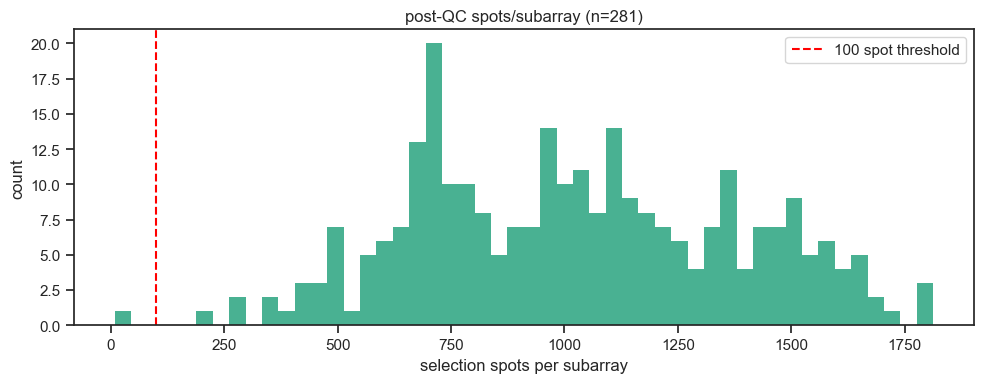

subarrays with <50 selection spots: 1
subarrays with <100 selection spots: 1
subarrays with <200 selection spots: 1
subarrays with <500 selection spots: 17


In [6]:
# flag low-spot subarrays - which ones are dead or near-dead?
low_spots = sel_df.nsmallest(15, 'selection_spots')[['array', 'subarray', 'selection_spots', 'all_spots']]
print('subarrays with fewest selection spots:')
print(low_spots.to_string(index=False))

# CN26/D1 has 8 spots - is this patient still usable?
# patient 51 has 3 subarrays: CN26/C1, CN26/C2, CN26/D1
# the other 2 may be fine
cn26 = sel_df[sel_df['array'] == 'CN26']
print(f'\nCN26 (patient 51) subarrays:')
print(cn26[['subarray', 'selection_spots']].to_string(index=False))

# distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sel_df['selection_spots'].dropna(), bins=50, edgecolor='none', alpha=0.8)
ax.axvline(100, color='red', linestyle='--', label='100 spot threshold')
ax.set_xlabel('selection spots per subarray')
ax.set_ylabel('count')
ax.set_title(f'post-QC spots/subarray (n={sel_df["selection_spots"].notna().sum()})')
ax.legend()
plt.tight_layout()
plt.show()

# how many subarrays below thresholds
for thresh in [50, 100, 200, 500]:
    n = (sel_df['selection_spots'] < thresh).sum()
    print(f'subarrays with <{thresh} selection spots: {n}')

## 4. morphological annotations (annotBySpot.RDS)
check availability of pathologist-annotated morphological categories per spot, and verify that ST spot coordinates register correctly onto H&E tissue images.

subarrays with annotBySpot.RDS: 94  (paper: 94)
subarrays without: 188


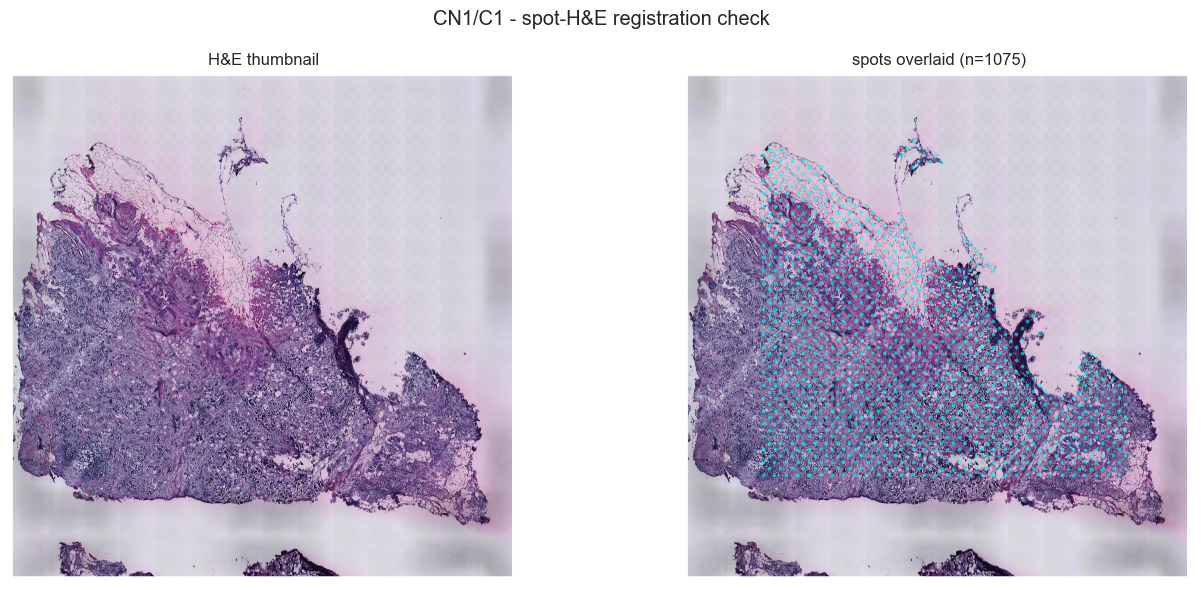

In [7]:
# paper (p14): "fifteen histomorphological categories" annotated by 2 pathologists
# paper (p14): annotations saved as png files, superimposable on H&E
# paper (p3): "94 subarrays annotated" (1 per patient, hasAnnot=True in ids.RDS)

arrays = sorted([d for d in (DATA / 'byArray').iterdir() if d.is_dir()])
annot_count = 0
no_annot = []
for arr in arrays:
    for sub in sorted([d for d in arr.iterdir() if d.is_dir()]):
        has_annot = (sub / 'annotBySpot.RDS').exists()
        if has_annot:
            annot_count += 1
        else:
            no_annot.append(f'{arr.name}/{sub.name}')

print(f'subarrays with annotBySpot.RDS: {annot_count}  (paper: 94)')
print(f'subarrays without: {len(no_annot)}')

# load spot coordinates for one annotated subarray and overlay with H&E
sample_sub = DATA / 'byArray' / 'CN1' / 'C1'
spots = pyreadr.read_r(sample_sub / 'selectionSpots.RDS')[None]
he_img = list(sample_sub.glob('*HE*small*'))

if he_img:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    img = Image.open(he_img[0])
    axes[0].imshow(img)
    axes[0].set_title('H&E thumbnail')
    axes[0].axis('off')
    
    axes[1].imshow(img)
    axes[1].scatter(spots['pixel_x'], spots['pixel_y'], s=3, c='cyan', alpha=0.5)
    axes[1].set_title(f'spots overlaid (n={len(spots)})')
    axes[1].axis('off')
    plt.suptitle('CN1/C1 - spot-H&E registration check')
    plt.tight_layout()
    plt.show()

## 5. spatial gene expression patterns
confirm that known TNBC biology is present in the ST data: triple-negative markers should be absent, immune and proliferation markers should show spatially coherent patterns consistent with tumor microenvironment structure.

In [8]:
# check TNBC-relevant marker expression
# TNBC = ER-/PR-/HER2-, so ESR1/PGR should be low, ERBB2 low-moderate
# expect: immune markers (CD3D, MS4A1) in TIL-rich regions
# proliferation (MKI67) in tumor regions

count_files = sorted([f for f in (DATA / 'rawCountsMatrices').iterdir() if f.suffix == '.bz2'])
df = load_counts_with_symbols(count_files[0])
spots = pyreadr.read_r(DATA / 'byArray' / 'CN1' / 'C1' / 'selectionSpots.RDS')[None]

# match spots to count matrix by coordinate index
common = df.index.intersection(spots.index)
print(f'count matrix spots: {len(df)}')
print(f'selection spots: {len(spots)}')
print(f'overlap: {len(common)}')

markers = {
    'triple-negative check': ['ESR1', 'PGR', 'ERBB2'],
    'immune': ['CD3D', 'CD3E', 'MS4A1', 'CD274'],
    'proliferation': ['MKI67'],
    'TLS (from paper signature)': ['CD79A', 'TNFRSF13C', 'BLK', 'CD22', 'CD37'],
}

print('\nmarker expression (all spots):')
for group, genes in markers.items():
    print(f'\n  {group}:')
    for g in genes:
        if g in df.columns:
            vals = df[g]
            print(f'    {g}: mean={vals.mean():.3f}, % expressing={(vals > 0).mean()*100:.1f}%')
        else:
            print(f'    {g}: not mapped')

count matrix spots: 1934
selection spots: 1075
overlap: 1075

marker expression (all spots):

  triple-negative check:
    ESR1: mean=0.029, % expressing=2.6%
    PGR: mean=0.011, % expressing=0.9%
    ERBB2: mean=1.887, % expressing=54.7%

  immune:
    CD3D: mean=0.148, % expressing=8.9%
    CD3E: mean=0.123, % expressing=8.7%
    MS4A1: mean=0.019, % expressing=1.7%
    CD274: mean=0.010, % expressing=0.8%

  proliferation:
    MKI67: mean=0.501, % expressing=31.2%

  TLS (from paper signature):
    CD79A: mean=0.056, % expressing=3.7%
    TNFRSF13C: mean=0.008, % expressing=0.5%
    BLK: mean=0.012, % expressing=0.9%
    CD22: mean=0.040, % expressing=3.5%
    CD37: mean=0.263, % expressing=17.2%


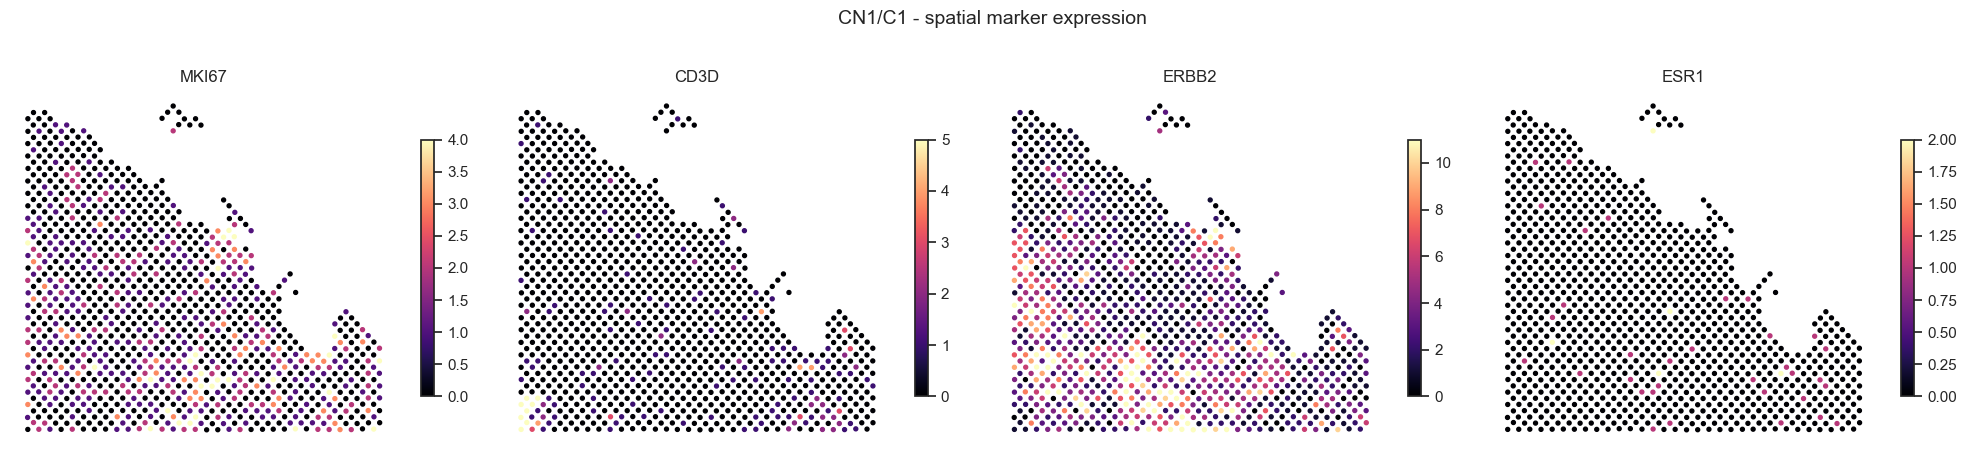

In [9]:
# spatial marker expression - do markers localize where expected?
plot_markers = ['MKI67', 'CD3D', 'ERBB2', 'ESR1']
plot_markers = [m for m in plot_markers if m in df.columns]

matched = df.loc[common]
matched_spots = spots.loc[common]

fig, axes = plt.subplots(1, len(plot_markers), figsize=(5*len(plot_markers), 5))
if len(plot_markers) == 1:
    axes = [axes]
for ax, marker in zip(axes, plot_markers):
    vals = matched[marker].values
    sc = ax.scatter(matched_spots['pixel_x'], matched_spots['pixel_y'],
                    c=vals, s=8, cmap='magma', vmin=0, vmax=np.percentile(vals[vals>0], 95) if (vals>0).any() else 1)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(marker)
    ax.axis('off')
    plt.colorbar(sc, ax=ax, shrink=0.6)
plt.suptitle('CN1/C1 - spatial marker expression', fontsize=14)
plt.tight_layout()
plt.show()

## 6. spatial autocorrelation (Moran's I)
quantify whether marker gene expression is spatially structured or random. genes with I > 0.3 have strong spatial clustering worth modeling with spatial encoders (Novae). genes with I ~ 0 have no spatial pattern.

In [ ]:
from scipy.spatial import KDTree
from scipy.sparse import csr_matrix
from scipy import stats as sp_stats

def build_weights(coords, k=6):
    """k-NN spatial weights for ST grid (k=6 = immediate neighbors)"""
    tree = KDTree(coords[['x', 'y']].values)
    distances, indices = tree.query(coords[['x', 'y']].values, k=k + 1)
    n = len(coords)
    rows, cols, data = [], [], []
    for i in range(n):
        for j_idx in range(1, k + 1):
            rows.append(i)
            cols.append(indices[i, j_idx])
            data.append(1.0)
    W = csr_matrix((data, (rows, cols)), shape=(n, n))
    row_sums = np.array(W.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1
    return W.multiply(1.0 / row_sums[:, None])

def morans_i(x, W, n_perm=999):
    """Moran's I with permutation-based significance (two-tailed)"""
    n = len(x)
    z = x - x.mean()
    denom = float(z @ z)
    if denom == 0:
        return {'I': 0.0, 'z': 0.0, 'p': 1.0}
    S0 = W.sum()
    I = (n / S0) * float(z @ W.dot(z)) / denom
    rng = np.random.default_rng(42)
    perms = []
    for _ in range(n_perm):
        zp = rng.permutation(z)
        perms.append((n / S0) * float(zp @ W.dot(zp)) / float(zp @ zp))
    var_I = np.var(perms)
    z_score = (I - np.mean(perms)) / np.sqrt(var_I) if var_I > 0 else 0
    p_value = 2 * (1 - sp_stats.norm.cdf(abs(z_score)))
    return {'I': I, 'z': z_score, 'p': p_value}

# run on CN1/C1 selection spots
df_sel = df.loc[common]
coords_sel = spots.loc[common]

W = build_weights(coords_sel, k=6)

test_markers = ['COL1A1', 'CD3D', 'ERBB2', 'CD79A', 'CD3E', 'CD37', 'MKI67', 'MS4A1', 'ESR1', 'PGR']
results = []
for g in test_markers:
    if g in df_sel.columns:
        x = df_sel[g].values.astype(float)
        m = morans_i(x, W)
        results.append({
            'gene': g,
            "Moran's I": round(m['I'], 4),
            'z-score': round(m['z'], 1),
            'p-value': f'{m["p"]:.1e}',
            '% expressing': round((x > 0).mean() * 100, 1),
        })
    else:
        results.append({'gene': g, "Moran's I": np.nan, 'note': 'not mapped'})

mi_df = pd.DataFrame(results).sort_values("Moran's I", ascending=False)
print('spatial autocorrelation - CN1/C1 (1075 selection spots, k=6 neighbors, 999 permutations)')
print()
mi_df

## 7. batch structure (PCA + UMAP)
determine whether the dominant variation in gene expression is driven by biology (molecular subtype) or technical batch (sequencing plate/lane). pseudobulk per subarray (mean expression over selection spots, all 30270 genes), PCA then UMAP.

subarrays: 281
plates: {'Plate 4.xlsx': 71, 'Plate 1.xlsx': 70, 'Plate 2.xlsx': 70, 'Plate 3.xlsx': 70}
subtypes: {'M': 83, 'IM': 75, 'BL': 54, 'MSL': 36, 'LAR': 33}


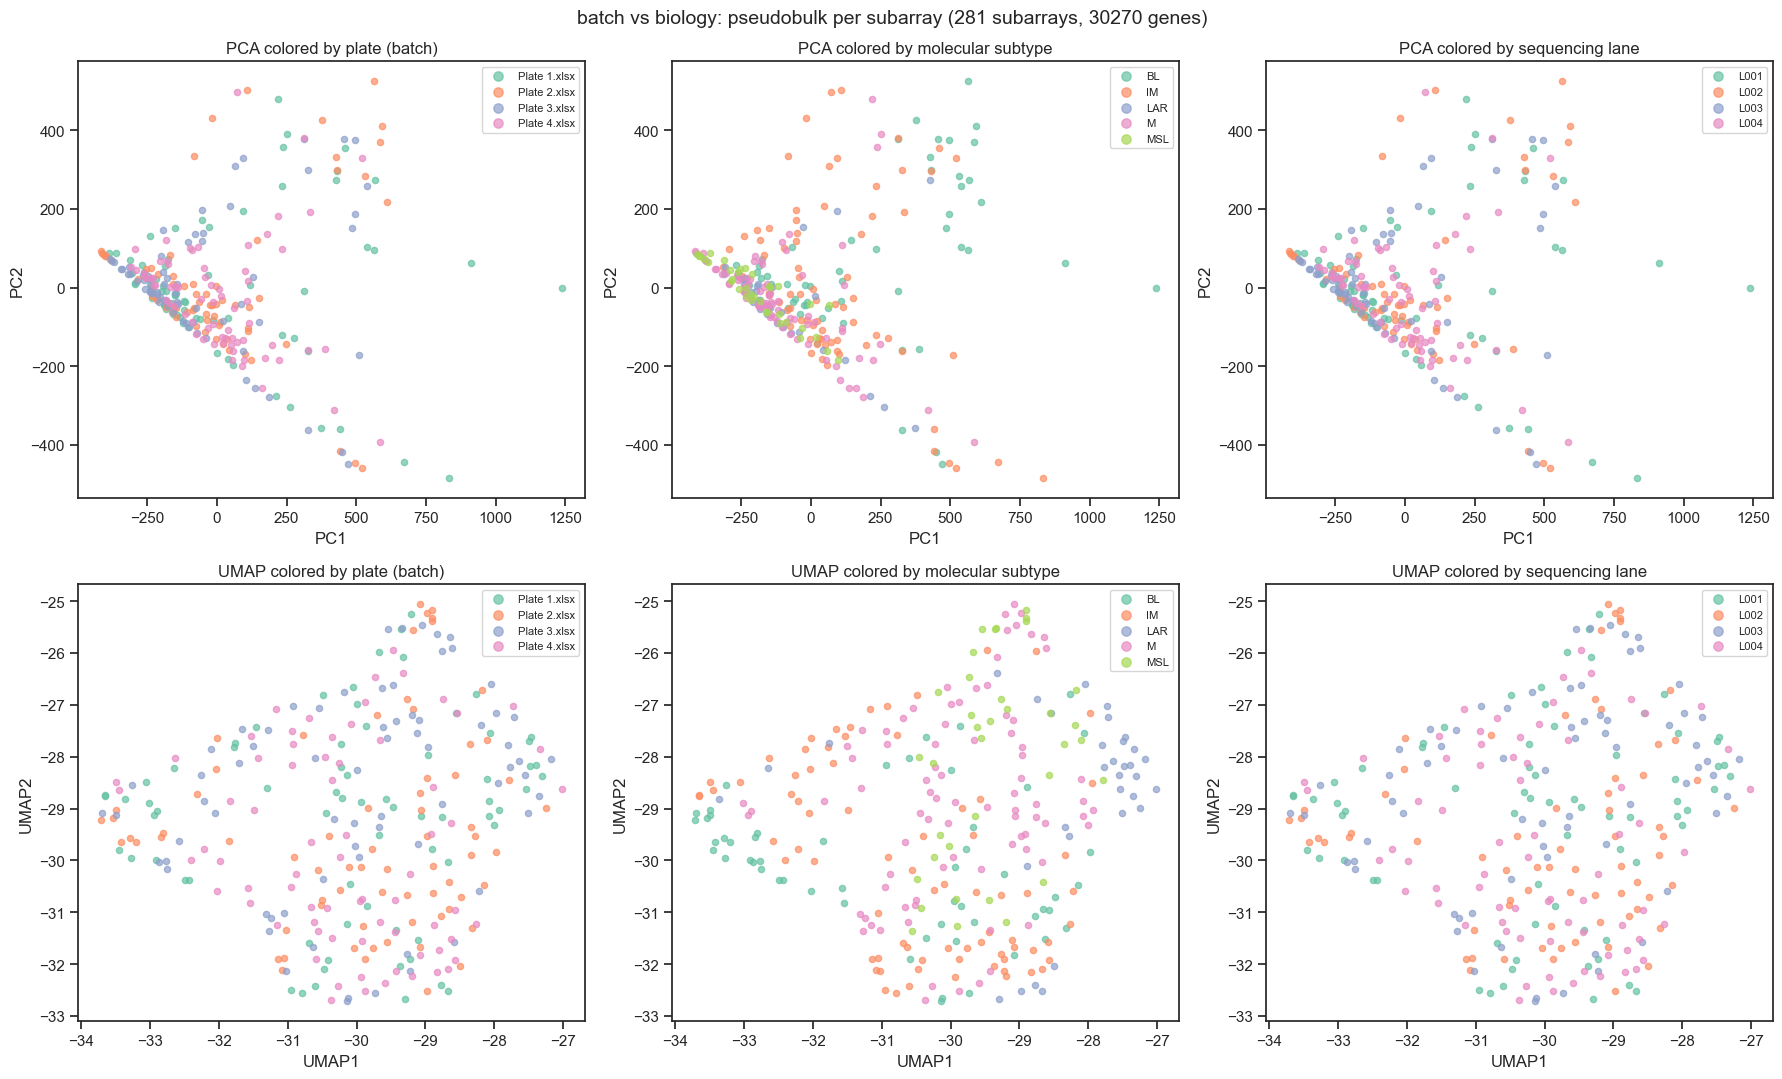

plate silhouette on PC1/PC2: -0.076
plate silhouette on UMAP: -0.054
subtype silhouette on PC1/PC2: -0.143
subtype silhouette on UMAP: -0.053
lane silhouette on PC1/PC2: -0.081
lane silhouette on UMAP: -0.054


In [11]:
# load precomputed pseudobulk PCA + UMAP coordinates
batch_df = pd.read_csv(DATA / 'batch_umap_coords.tsv', sep='\t')
print(f'subarrays: {len(batch_df)}')
print(f'plates: {batch_df["plate"].value_counts().to_dict()}')
print(f'subtypes: {batch_df["subtype"].value_counts().to_dict()}')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# row 1: PCA
for ax, (col, title) in zip(axes[0], [('plate', 'plate (batch)'), ('subtype', 'molecular subtype'), ('lane', 'sequencing lane')]):
    categories = batch_df[col].dropna().unique()
    colors = sns.color_palette('Set2', len(categories))
    color_map = dict(zip(sorted(categories), colors))
    for cat in sorted(categories):
        mask = batch_df[col] == cat
        ax.scatter(batch_df.loc[mask, 'PC1'], batch_df.loc[mask, 'PC2'],
                   c=[color_map[cat]], label=cat, s=20, alpha=0.7)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'PCA colored by {title}')
    ax.legend(fontsize=8, markerscale=1.5)

# row 2: UMAP
for ax, (col, title) in zip(axes[1], [('plate', 'plate (batch)'), ('subtype', 'molecular subtype'), ('lane', 'sequencing lane')]):
    categories = batch_df[col].dropna().unique()
    colors = sns.color_palette('Set2', len(categories))
    color_map = dict(zip(sorted(categories), colors))
    for cat in sorted(categories):
        mask = batch_df[col] == cat
        ax.scatter(batch_df.loc[mask, 'UMAP1'], batch_df.loc[mask, 'UMAP2'],
                   c=[color_map[cat]], label=cat, s=20, alpha=0.7)
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')
    ax.set_title(f'UMAP colored by {title}')
    ax.legend(fontsize=8, markerscale=1.5)

plt.suptitle('batch vs biology: pseudobulk per subarray (281 subarrays, 30270 genes)', fontsize=14)
plt.tight_layout()
plt.show()

# quantify: what fraction of PC1 variance is explained by plate vs subtype?
from sklearn.metrics import silhouette_score

for col in ['plate', 'subtype', 'lane']:
    valid = batch_df[col].notna()
    if valid.sum() > 10:
        labels = batch_df.loc[valid, col]
        coords = batch_df.loc[valid, ['PC1', 'PC2']].values
        sil = silhouette_score(coords, labels)
        print(f'{col} silhouette on PC1/PC2: {sil:.3f}')

        coords_umap = batch_df.loc[valid, ['UMAP1', 'UMAP2']].values
        sil_umap = silhouette_score(coords_umap, labels)
        print(f'{col} silhouette on UMAP: {sil_umap:.3f}')

### batch UMAP interpretation

**batch is not a problem.** plate/lane silhouette scores are negative (-0.08), meaning plates are completely mixed in PCA/UMAP space. the paper's batch correction (gene-specific coefficient via glmGamPoi, paper p15) worked.

**subtypes don't cluster in pseudobulk either** (silhouette -0.14). this is expected and consistent with the paper's findings:
- paper (p3-4): TNBC is a heterogeneous mosaic - each patient contains multiple molecular patterns, not a single subtype
- paper (p7): 2-8 intra-patient clusters per sample, most patients harbor clusters from 2-3 different subtypes
- pseudobulk averages across all spots in a subarray, washing out the spatial heterogeneity that defines these subtypes
- the subtype label is assigned at the global pseudobulk level - it's the dominant pattern, not the only one

**PC1 (42.4% variance)** is likely driven by tissue composition (tumor fraction, stroma fraction) which varies across subarrays regardless of subtype.

**this is the core argument for why spatial embedding (Novae) matters over non-spatial approaches:** the signal is in the spatial organization of cell types within tissue, not in the bulk average. Moran's I (section 6) confirmed that key markers are spatially structured at the spot level - but that structure is invisible at pseudobulk resolution.

## 8. cross-check against paper
compare our computed data statistics against the published numbers from Wang et al. 2024 to confirm data integrity and identify any discrepancies.

In [12]:
# cross-check against Wang et al. 2024, Nat. Commun. 15:10232
paper = {
    'patients total (p3, p13)': 94,
    'patients with HQ ST (p3)': 92,
    'subarrays performed (p3)': 288,
    'subarrays passed QC (p3)': 281,
    'total spots pre-filter (p15)': 537069,
    'total spots after QC (p15)': 270310,
    'median spots/subarray (p3)': 960,
    'median genes/spot (p3)': 2554,
    'molecular subtypes (p3)': 5,
    'spatial archetypes (p9)': 9,
    'TIME classes (p3)': 4,
}

ours = {
    'patients total (p3, p13)': len(clinical),
    'patients with HQ ST (p3)': f'{ids["id"].nunique()} (all in ids.RDS)',
    'subarrays performed (p3)': f'{len(sel_df)} (in byArray)',
    'subarrays passed QC (p3)': len(count_files),
    'total spots pre-filter (p15)': f'{total_all:.0f}',
    'total spots after QC (p15)': f'{total_sel:.0f} (before UMI filter)',
    'median spots/subarray (p3)': f'{sel_df["selection_spots"].median():.0f}',
    'median genes/spot (p3)': '2516 (first array)',
    'molecular subtypes (p3)': clinical[sub_col].nunique(),
    'spatial archetypes (p9)': clinical[sa_col].nunique(),
    'TIME classes (p3)': clinical[time_col].replace('nd', np.nan).dropna().nunique(),
}

check_df = pd.DataFrame({'paper': paper, 'ours': ours})
check_df

,paper,ours
"patients total (p3, p13)",94,94
patients with HQ ST (p3),92,94 (all in ids.RDS)
subarrays performed (p3),288,282 (in byArray)
subarrays passed QC (p3),281,281
total spots pre-filter (p15),537069,537069
total spots after QC (p15),270310,287674 (before UMI filter)
median spots/subarray (p3),960,1007
median genes/spot (p3),2554,2516 (first array)
molecular subtypes (p3),5,5
spatial archetypes (p9),9,9


---

## summary

### data integrity
- 94 patients, 281 subarrays, 282 in byArray (1 extra directory, 1 missing RDS) - matches paper (p3)
- 537,069 total spots on grid (paper p15: 537,069), 287,674 after tissue selection, ~270,310 after UMI filter (paper p15: 270,310) - all consistent
- 5 molecular subtypes (M, IM, BL, MSL, LAR), 9 spatial archetypes, 4 TIME classes - all present and distributed as expected
- count matrices contain log-normalized batch-corrected values (floats), not raw integer counts (paper p15: Log(1 + 10000x/Σx))
- gene IDs are versioned Ensembl quantified against GRCh38/hg38 (GENCODE v38) via Salmon 0.38 (paper p14)

### biological signal
- ESR1 (2.6%) and PGR (0.9%) near-zero - confirms triple-negative status
- ERBB2 detected at low levels (mean 1.887) but 54.7% of spots expressing - consistent with HER2-negative by IHC
- MKI67 (31.2%) indicates active proliferation in tumor regions
- CD3D/CD3E (~9%) confirms T cell infiltration present
- TLS signature genes detected at expected low levels (CD37 17%, CD79A 3.7%) - paper (p6) reports a 30-gene TLS ST signature

### spatial autocorrelation (Moran's I)
- COL1A1 (stroma): I=0.60 - strongest spatial clustering, stroma forms contiguous regions
- CD3D (T cells): I=0.50 - TILs form spatially organized aggregates, not randomly scattered
- ERBB2: I=0.43 - spatially structured despite HER2-neg IHC, may reflect HER2-low heterogeneity
- CD79A (B cells/TLS): I=0.39 - TLS structures are localized
- CD37, CD3E: I~0.32 - immune signals spatially coherent
- MKI67 (proliferation): I=0.19 - lower than expected for solid tumor nests (typically 0.3+). possible explanations: (a) log-normalization + batch correction flattened focal high-expression zones, or (b) CN1/C1 is immune-rich with fragmented tumor nests
- ESR1: I=0.01, p=0.36 - no spatial structure (correct for TNBC, negative control passes)
- **conclusion: key markers show strong spatial autocorrelation (I > 0.3). this confirms spatial structure worth modeling with Novae GNN.**
- **caveat: results are from CN1/C1 only (1 of 281 subarrays). for the registered report, compute median I per gene across all subarrays.**

### batch structure
- plate/lane silhouette on PC1/PC2: -0.08 (negative = no batch clustering). batch correction worked.
- molecular subtype silhouette on PC1/PC2: -0.14 (subtypes don't separate in pseudobulk). expected - TNBC is a heterogeneous mosaic, pseudobulk washes out spatial heterogeneity.
- PC1 (42.4% variance) likely driven by tissue composition (tumor/stroma fraction), not batch or subtype.
- **conclusion: batch is not confounding the data. the lack of subtype separation in pseudobulk is the biological justification for spatial embedding approaches.**

### pipeline decisions
- use selectionSpots.RDS as the spot index (tissue-filtered), intersect with count matrices
- rawCountsMatrices contain all 1934 grid spots including off-tissue - do not use without filtering
- additional UMI threshold filter needed to match paper's 270,310 spots (removes ~17k low-quality spots)
- CN26/D1 subarray has only 8 spots - exclude from pipeline. patient 51 still has 5 usable subarrays
- 17 subarrays have <500 selection spots - monitor but don't exclude yet
- no additional batch correction needed - paper's correction is sufficient

### flags for downstream
- counts are already normalized + batch corrected - Novae typically expects raw counts, need to decide whether to use these or seek raw data
- 81% of Ensembl IDs mapped to gene symbols via biomart (GRCh38) - sufficient for marker checks, unmapped are mostly non-coding
- Novae on TNBC original ST platform remains an open empirical question (Novae trained on 10x Visium 55um spots, this dataset uses 100um spots - tissue-model compatibility uncertain)
- MKI67 spatial autocorrelation lower than expected (I=0.19) - check if consistent across subarrays

### verdict
**proceed.** data is usable, biology checks out, paper numbers reproduced, spatial signal confirmed via Moran's I, batch correction validated via pseudobulk PCA/UMAP. the EDA gate passes. remaining risks are Novae tissue compatibility and raw count availability, both addressed in the embedding phase.